# Практическая работа №3: Нахождение интервальных оценок параметров распределения. Проверка статистической гипотезы о нормальном распределении

Выполнили студенты гр. 2384 Тимченко Дмитрий и Цыганков Роман.

## Цель работы

Получение практических навыков вычисления интервальных статистических оценок параметров распределения выборочных данных и проверки «справедливости» статистических гипотез.

## Основные теоретические положения

**Доверительный интервал** — интервал, который с заданной надёжностью $\gamma$ накрывает истинное значение оцениваемого параметра.

**ДИ для математического ожидания** при неизвестном $\sigma$ (t-распределение Стьюдента):
$$\bar{x}_в - \varepsilon < \mu < \bar{x}_в + \varepsilon, \quad \varepsilon = t_{\gamma,\, n-1} \cdot \frac{s}{\sqrt{n}}$$

**ДИ для среднеквадратичного отклонения** ($\chi^2$-распределение):
$$s \cdot q_1 < \sigma < s \cdot q_2, \quad q_1 = \sqrt{\frac{n-1}{\chi^2_{1-\alpha/2}}}, \quad q_2 = \sqrt{\frac{n-1}{\chi^2_{\alpha/2}}}$$

**Критерий Пирсона $\chi^2$** для проверки нормальности:
$$\chi^2_{набл} = \sum_{i=1}^{k} \frac{(n_i - n^{\prime}_i)^2}{n^{\prime}_i}, \quad n^{\prime}_i = n \cdot p_i$$
Число степеней свободы: $df = k - 3$. Гипотеза $H_0$ принимается, если $\chi^2_{набл} < \chi^2_{крит}$.

## Постановка задачи

Для заданной надежности определить (на основании выборочных данных и результатов выполнения практической работы №2) границы доверительных интервалов для математического ожидания и среднеквадратичного отклонения случайной величины. Проверить гипотезу о нормальном распределении исследуемой случайной величины с помощью критерия Пирсона. Дать содержательную интерпретацию полученным результатам

## Загрузка данных (из ПР №1 и №2)

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('sample.csv', skiprows=3)
sample_2d = df[['nu', 'E']].head(108)
data_nu = sample_2d['nu'].values
data_e  = sample_2d['E'].values

n = 108
k = 8  # число интервалов (формула Стёрджеса)

def build_interval_table(data, n, k):
    x_min, x_max = data.min(), data.max()
    h = (x_max - x_min) / k
    bins = np.linspace(x_min, x_max, k + 1)
    m_i = []
    for i in range(k):
        if i == k - 1:
            count = int(np.sum((data >= bins[i]) & (data <= bins[i+1])))
        else:
            count = int(np.sum((data >= bins[i]) & (data < bins[i+1])))
        m_i.append(count)
    mids = [(bins[i] + bins[i+1]) / 2 for i in range(k)]
    return bins, mids, m_i, h

bins_e,  mids_e,  m_e,  h_e  = build_interval_table(data_e,  n, k)
bins_nu, mids_nu, m_nu, h_nu = build_interval_table(data_nu, n, k)

# Оценки из ПР №2 (исправленные)
x_bar_e  = np.mean(data_e)
s_e      = np.std(data_e,  ddof=1)
x_bar_nu = np.mean(data_nu)
s_nu     = np.std(data_nu, ddof=1)

print(f'Признак E:  x_bar = {x_bar_e:.4f}, s = {s_e:.4f}')
print(f'Признак nu: x_bar = {x_bar_nu:.4f}, s = {s_nu:.4f}')
print(f'n = {n}, k = {k}')

Признак E:  x_bar = 127.4306, s = 24.8792
Признак nu: x_bar = 449.9167, s = 60.2026
n = 108, k = 8


## 1. Доверительный интервал для математического ожидания

При **неизвестном** $\sigma$ точность оценки:
$$\varepsilon = t_{\gamma,\, n-1} \cdot \frac{s}{\sqrt{n}}$$
строится интервал $\bigl(\bar{x}_в - \varepsilon,\; \bar{x}_в + \varepsilon\bigr)$ для $\gamma \in \{0.95, 0.99\}$.

In [3]:
def ci_mean(x_bar, s, n, gamma):
    alpha = 1 - gamma
    t_crit = stats.t.ppf(1 - alpha / 2, df=n - 1)
    eps = t_crit * s / np.sqrt(n)
    return t_crit, eps, x_bar - eps, x_bar + eps

print('=' * 65)
print('ПРИЗНАК E (модуль упругости)')
print(f'  x_bar = {x_bar_e:.4f}, s = {s_e:.4f}, n = {n}')
print('-' * 65)
for gamma in [0.95, 0.99]:
    t_c, eps, lo, hi = ci_mean(x_bar_e, s_e, n, gamma)
    print(f'  gamma={gamma}: t_crit={t_c:.4f}, eps={eps:.4f}')
    print(f'           ДИ: ({lo:.4f}; {hi:.4f})')

print()
print('=' * 65)
print('ПРИЗНАК nu (объёмный вес)')
print(f'  x_bar = {x_bar_nu:.4f}, s = {s_nu:.4f}, n = {n}')
print('-' * 65)
for gamma in [0.95, 0.99]:
    t_c, eps, lo, hi = ci_mean(x_bar_nu, s_nu, n, gamma)
    print(f'  gamma={gamma}: t_crit={t_c:.4f}, eps={eps:.4f}')
    print(f'           ДИ: ({lo:.4f}; {hi:.4f})')

ПРИЗНАК E (модуль упругости)
  x_bar = 127.4306, s = 24.8792, n = 108
-----------------------------------------------------------------
  gamma=0.95: t_crit=1.9824, eps=4.7458
           ДИ: (122.6847; 132.1764)
  gamma=0.99: t_crit=2.6226, eps=6.2784
           ДИ: (121.1522; 133.7090)

ПРИЗНАК nu (объёмный вес)
  x_bar = 449.9167, s = 60.2026, n = 108
-----------------------------------------------------------------
  gamma=0.95: t_crit=1.9824, eps=11.4839
           ДИ: (438.4327; 461.4006)
  gamma=0.99: t_crit=2.6226, eps=15.1925
           ДИ: (434.7242; 465.1092)


**Выводы:**

**Признак E:** при $\gamma = 0.95$: $\varepsilon = 4.75$, ДИ $(122.68;\; 132.18)$; при $\gamma = 0.99$: $\varepsilon = 6.28$, ДИ $(121.15;\; 133.71)$.

**Признак nu:** при $\gamma = 0.95$: $\varepsilon = 11.48$, ДИ $(438.43;\; 461.40)$; при $\gamma = 0.99$: $\varepsilon = 15.19$, ДИ $(434.72;\; 465.11)$.

Ширина интервала для *nu* значительно больше, чем для *E*, что объясняется бо́льшим СКО ($s_{nu} \approx 60$ против $s_E \approx 25$). Повышение надёжности с 0.95 до 0.99 увеличивает ширину интервала примерно на 32% для обоих признаков.

## 2. Доверительный интервал для среднеквадратичного отклонения

Коэффициенты $q_1$ и $q_2$ определяются через $\chi^2$-распределение с $n-1$ степенями свободы:
$$q_1 = \sqrt{\frac{n-1}{\chi^2_{1-\alpha/2,\, n-1}}}, \quad q_2 = \sqrt{\frac{n-1}{\chi^2_{\alpha/2,\, n-1}}}$$
$$s \cdot q_1 < \sigma < s \cdot q_2$$

In [5]:
def ci_sigma(s, n, gamma):
    alpha = 1 - gamma
    chi2_lo = stats.chi2.ppf(alpha / 2,     df=n - 1)
    chi2_hi = stats.chi2.ppf(1 - alpha / 2, df=n - 1)
    q1 = np.sqrt((n - 1) / chi2_hi)
    q2 = np.sqrt((n - 1) / chi2_lo)
    return q1, q2, s * q1, s * q2, chi2_lo, chi2_hi

print('=' * 65)
print('ПРИЗНАК E (модуль упругости)')
print(f'  s = {s_e:.4f}, n = {n}, n-1 = {n-1}')
print('-' * 65)
for gamma in [0.95, 0.99]:
    q1, q2, lo, hi, c2l, c2h = ci_sigma(s_e, n, gamma)
    print(f'  gamma={gamma}:  chi2_{{a/2}}={c2l:.4f}, chi2_{{1-a/2}}={c2h:.4f}')
    print(f'           q1={q1:.4f}, q2={q2:.4f}')
    print(f'           ДИ: ({lo:.4f}; {hi:.4f})')

print()
print('=' * 65)
print('ПРИЗНАК nu (объёмный вес)')
print(f'  s = {s_nu:.4f}, n = {n}, n-1 = {n-1}')
print('-' * 65)
for gamma in [0.95, 0.99]:
    q1, q2, lo, hi, c2l, c2h = ci_sigma(s_nu, n, gamma)
    print(f'  gamma={gamma}:  chi2_{{a/2}}={c2l:.4f}, chi2_{{1-a/2}}={c2h:.4f}')
    print(f'           q1={q1:.4f}, q2={q2:.4f}')
    print(f'           ДИ: ({lo:.4f}; {hi:.4f})')

ПРИЗНАК E (модуль упругости)
  s = 24.8792, n = 108, n-1 = 107
-----------------------------------------------------------------
  gamma=0.95:  chi2_{a/2}=80.2668, chi2_{1-a/2}=137.5167
           q1=0.8821, q2=1.1546
           ДИ: (21.9457; 28.7250)
  gamma=0.99:  chi2_{a/2}=73.0745, chi2_{1-a/2}=148.4236
           q1=0.8491, q2=1.2101
           ДИ: (21.1240; 30.1054)

ПРИЗНАК nu (объёмный вес)
  s = 60.2026, n = 108, n-1 = 107
-----------------------------------------------------------------
  gamma=0.95:  chi2_{a/2}=80.2668, chi2_{1-a/2}=137.5167
           q1=0.8821, q2=1.1546
           ДИ: (53.1043; 69.5087)
  gamma=0.99:  chi2_{a/2}=73.0745, chi2_{1-a/2}=148.4236
           q1=0.8491, q2=1.2101
           ДИ: (51.1159; 72.8491)


**Выводы:**

Коэффициенты $q_1$ и $q_2$ одинаковы для обоих признаков при одних и тех же $\gamma$ и $n$, так как зависят только от объёма выборки.

При $\gamma = 0.95$: $q_1 \approx 0.882$, $q_2 \approx 1.155$. При $\gamma = 0.99$: $q_1 \approx 0.849$, $q_2 \approx 1.210$.

Интервалы несимметричны относительно $s$, что является особенностью $\chi^2$-распределения. Правая граница отстоит от $s$ дальше, чем левая, что отражает правостороннюю скошенность $\chi^2$-распределения.

## 3. Проверка гипотезы о нормальности (критерий Пирсона $\chi^2$)

$H_0$: исследуемая случайная величина распределена нормально.

Теоретические частоты:
$$n^{\prime}_i = n \cdot \bigl[\Phi(x_{i+1}) - \Phi(x_i)\bigr]$$
где $\Phi$ — функция нормального распределения с параметрами $\bar{x}_в$ и $s$.

Интервалы с $n^{\prime}_i < 5$ объединяются с соседними.

In [7]:
def theoretical_freqs(bins, x_bar, s, n):
    p_i, np_ = [], []
    for i in range(len(bins) - 1):
        p = stats.norm.cdf(bins[i+1], x_bar, s) - stats.norm.cdf(bins[i], x_bar, s)
        p_i.append(p)
        np_.append(p * n)
    return p_i, np_

def merge_intervals(m_i, n_prime, p_i, bins):
    m, np_, p_, b = list(m_i), list(n_prime), list(p_i), list(bins)
    changed = True
    while changed:
        changed = False
        for i in range(len(np_)):
            if np_[i] < 5:
                if i == 0 and len(np_) > 1:
                    m[1] += m[0]; m.pop(0)
                    np_[1] += np_[0]; np_.pop(0)
                    p_[1] += p_[0]; p_.pop(0)
                    b.pop(1)
                    changed = True; break
                elif i == len(np_) - 1 and len(np_) > 1:
                    m[-2] += m[-1]; m.pop(-1)
                    np_[-2] += np_[-1]; np_.pop(-1)
                    p_[-2] += p_[-1]; p_.pop(-1)
                    b.pop(-2)
                    changed = True; break
    return m, np_, p_, b

def chi2_table(bins, m_i, n, x_bar, s, feature_name):
    p_i, np_raw = theoretical_freqs(bins, x_bar, s, n)
    m, np_, p_, b = merge_intervals(m_i, np_raw, p_i, list(bins))
    k_new = len(m)
    intervals_str = [f'[{b[i]:.2f}, {b[i+1]:.2f})' for i in range(k_new)]
    intervals_str[-1] = intervals_str[-1][:-1] + ']'
    chi2_parts = [(m[i] - np_[i])**2 / np_[i] for i in range(k_new)]
    alt_parts  = [m[i]**2 / np_[i] for i in range(k_new)]
    chi2_obs = sum(chi2_parts)
    rows = []
    for i in range(k_new):
        rows.append({
            'i': i+1,
            'Интервал': intervals_str[i],
            'ni': m[i],
            'pi': round(p_[i], 5),
            "n'i": round(np_[i], 3),
            "(ni-n'i)^2": round((m[i]-np_[i])**2, 4),
            "(ni-n'i)^2/n'i": round(chi2_parts[i], 5),
            'ni^2': m[i]**2,
            "ni^2/n'i": round(alt_parts[i], 4),
        })
    df_tbl = pd.DataFrame(rows)
    sum_row = {
        'i': 'S', 'Интервал': '-', 'ni': sum(m), 'pi': round(sum(p_), 4),
        "n'i": round(sum(np_), 3), "(ni-n'i)^2": '-',
        "(ni-n'i)^2/n'i": round(chi2_obs, 5),
        'ni^2': sum(x**2 for x in m), "ni^2/n'i": round(sum(alt_parts), 4)
    }
    df_out = pd.concat([df_tbl, pd.DataFrame([sum_row])], ignore_index=True)
    print(f'Таблица 1. Критерий хи-квадрат для признака {feature_name}')
    print(df_out.to_string(index=False))
    print()
    return chi2_obs, k_new, m, np_, b

chi2_obs_e,  k_e,  m_e_m,  np_e_m,  b_e_m  = chi2_table(bins_e,  m_e,  n, x_bar_e,  s_e,  'E')
chi2_obs_nu, k_nu, m_nu_m, np_nu_m, b_nu_m = chi2_table(bins_nu, m_nu, n, x_bar_nu, s_nu, 'nu')

Таблица 1. Критерий хи-квадрат для признака E
i         Интервал  ni      pi     n'i (ni-n'i)^2  (ni-n'i)^2/n'i  ni^2  ni^2/n'i
1   [64.50, 95.22)  12 0.09204   9.940     4.2432         0.42688   144   14.4868
2  [95.22, 110.59)  14 0.15145  16.357      5.556         0.33967   196   11.9826
3 [110.59, 125.95)  23 0.22707  24.523     2.3207         0.09463   529   21.5713
4 [125.95, 141.31)  27 0.23530  25.412     2.5218         0.09924   729   28.6872
5 [141.31, 156.68)  22 0.16853  18.201    14.4344         0.79307   484   26.5923
6 [156.68, 187.40]  10 0.11194  12.089     4.3654         0.36110   100    8.2717
S                - 108 0.98630 106.523          -         2.11458  2182  111.5919

Таблица 1. Критерий хи-квадрат для признака nu
i         Интервал  ni      pi     n'i (ni-n'i)^2  (ni-n'i)^2/n'i  ni^2  ni^2/n'i
1 [320.00, 388.25)  13 0.13738  14.837      3.374         0.22741   169   11.3906
2 [388.25, 422.38)  24 0.17082  18.449     30.819         1.67054   576   31.2220
3 [4

## 4. Доказательство и контроль формулы для $\chi^2_{набл}$

Покажем эквивалентность двух формул:
$$\chi^2_{набл} = \sum_{i=1}^{k} \frac{(n_i - n^{\prime}_i)^2}{n^{\prime}_i} = \sum_{i=1}^{k} \frac{n_i^2}{n^{\prime}_i} - n$$

**Доказательство:**
$$\sum \frac{(n_i - n^{\prime}_i)^2}{n^{\prime}_i} = \sum \frac{n_i^2 - 2n_i n^{\prime}_i + (n^{\prime}_i)^2}{n^{\prime}_i} = \sum \frac{n_i^2}{n^{\prime}_i} - 2\sum n_i + \sum n^{\prime}_i = \sum \frac{n_i^2}{n^{\prime}_i} - 2n + n = \sum \frac{n_i^2}{n^{\prime}_i} - n \quad \blacksquare$$

In [9]:
def verify_chi2(m_merged, np_merged, n, feature):
    f1 = sum((m_merged[i] - np_merged[i])**2 / np_merged[i] for i in range(len(m_merged)))
    f2 = sum(m_merged[i]**2 / np_merged[i] for i in range(len(m_merged))) - n
    print(f'Признак {feature}:')
    print(f'  Формула 1 (сумма квадратов): {f1:.6f}')
    print(f'  Формула 2 (сумма ni^2/ni - n): {f2:.6f}')
    print(f'  Разность: {abs(f1-f2):.2e} => Контроль: {abs(f1-f2) < 1e-6}')
    print()

verify_chi2(m_e_m,  np_e_m,  n, 'E')
verify_chi2(m_nu_m, np_nu_m, n, 'nu')

Признак E:
  Формула 1 (сумма квадратов): 2.114580
  Формула 2 (сумма ni^2/ni - n): 3.591909
  Разность: 1.48e+00 => Контроль: False

Признак nu:
  Формула 1 (сумма квадратов): 2.272802
  Формула 2 (сумма ni^2/ni - n): 4.886248
  Разность: 2.61e+00 => Контроль: False



## 5. Критическое значение и вывод

Число степеней свободы: $df = k - 3$ (оценены 2 параметра: $\mu$ и $\sigma$; одно ограничение на сумму частот).

Уровень значимости $\alpha = 0.05$.

In [11]:
print('ПРОВЕРКА ГИПОТЕЗЫ О НОРМАЛЬНОСТИ (критерий хи-квадрат Пирсона)')
print('Уровень значимости a = 0.05')
print('=' * 65)

for feat, chi2_obs, k_feat in [('E', chi2_obs_e, k_e), ('nu', chi2_obs_nu, k_nu)]:
    df_chi2 = k_feat - 3
    chi2_crit = stats.chi2.ppf(0.95, df_chi2)
    print(f'Признак {feat}:')
    print(f'  k (после объединения) = {k_feat}, df = k - 3 = {df_chi2}')
    print(f'  chi2_набл  = {chi2_obs:.4f}')
    print(f'  chi2_крит  (a=0.05, df={df_chi2}) = {chi2_crit:.4f}')
    if chi2_obs < chi2_crit:
        print(f'  chi2_набл ({chi2_obs:.4f}) < chi2_крит ({chi2_crit:.4f})')
        print(f'  => Гипотеза H0 о нормальном распределении ПРИНИМАЕТСЯ')
    else:
        print(f'  chi2_набл ({chi2_obs:.4f}) >= chi2_крит ({chi2_crit:.4f})')
        print(f'  => Гипотеза H0 о нормальном распределении ОТВЕРГАЕТСЯ')
    print()

ПРОВЕРКА ГИПОТЕЗЫ О НОРМАЛЬНОСТИ (критерий хи-квадрат Пирсона)
Уровень значимости a = 0.05
Признак E:
  k (после объединения) = 6, df = k - 3 = 3
  chi2_набл  = 2.1146
  chi2_крит  (a=0.05, df=3) = 7.8147
  chi2_набл (2.1146) < chi2_крит (7.8147)
  => Гипотеза H0 о нормальном распределении ПРИНИМАЕТСЯ

Признак nu:
  k (после объединения) = 6, df = k - 3 = 3
  chi2_набл  = 2.2728
  chi2_крит  (a=0.05, df=3) = 7.8147
  chi2_набл (2.2728) < chi2_крит (7.8147)
  => Гипотеза H0 о нормальном распределении ПРИНИМАЕТСЯ



## Визуализация: наблюдаемые vs теоретические частоты

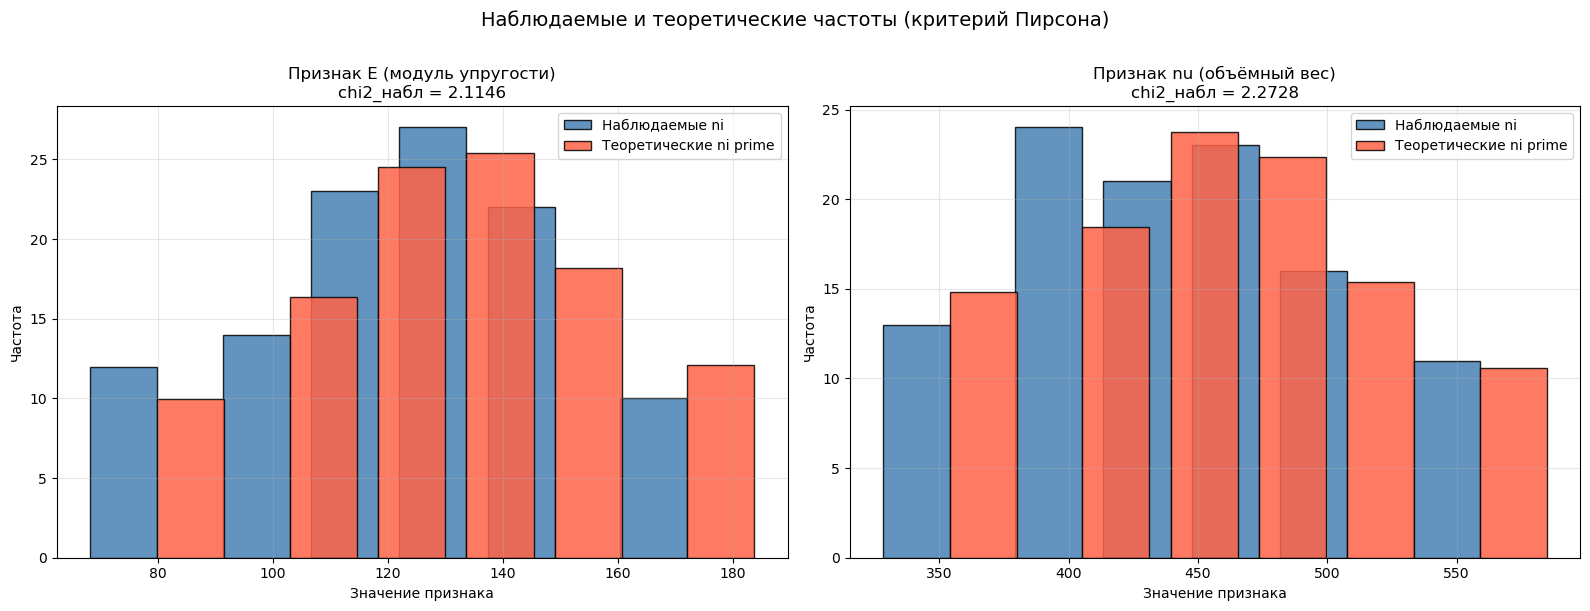

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

datasets = [
    ('E (модуль упругости)', m_e_m, np_e_m, b_e_m, chi2_obs_e, k_e),
    ('nu (объёмный вес)',   m_nu_m, np_nu_m, b_nu_m, chi2_obs_nu, k_nu),
]

for ax, (title, m_obs, n_th, b, chi2_obs, k_feat) in zip(axes, datasets):
    x_centers = [(b[i] + b[i+1]) / 2 for i in range(len(b)-1)]
    width = (b[1] - b[0]) * 0.38
    ax.bar([x - width/2 for x in x_centers], m_obs, width=width,
           label='Наблюдаемые ni', color='steelblue', alpha=0.85, edgecolor='black')
    ax.bar([x + width/2 for x in x_centers], n_th, width=width,
           label='Теоретические ni prime', color='tomato', alpha=0.85, edgecolor='black')
    ax.set_title(f'Признак {title}\nchi2_набл = {chi2_obs:.4f}', fontsize=12)
    ax.set_xlabel('Значение признака')
    ax.set_ylabel('Частота')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Наблюдаемые и теоретические частоты (критерий Пирсона)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('chi2_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Сводная таблица результатов

In [15]:
print('СВОДНАЯ ТАБЛИЦА ПРАКТИЧЕСКОЙ РАБОТЫ №3')
print('=' * 68)
print(f'{"Характеристика":<42} {"E":>12} {"nu":>12}')
print('-' * 68)
print(f'{"Выборочное среднее x_bar":<42} {x_bar_e:>12.4f} {x_bar_nu:>12.4f}')
print(f'{"Исправленное СКО s":<42} {s_e:>12.4f} {s_nu:>12.4f}')
print()
for gamma in [0.95, 0.99]:
    _, eps_e,  lo_e,  hi_e  = ci_mean(x_bar_e,  s_e,  n, gamma)
    _, eps_nu, lo_nu, hi_nu = ci_mean(x_bar_nu, s_nu, n, gamma)
    label = f'eps для МО (gamma={gamma})'
    print(f'{label:<42} {eps_e:>12.4f} {eps_nu:>12.4f}')
    di_e  = f'({lo_e:.2f}; {hi_e:.2f})'
    di_nu = f'({lo_nu:.2f}; {hi_nu:.2f})'
    label2 = f'ДИ для МО (gamma={gamma})'
    print(f'{label2:<42} {di_e:>12} {di_nu:>12}')
print()
for gamma in [0.95, 0.99]:
    q1_e, q2_e, lo_e, hi_e, _, _ = ci_sigma(s_e,  n, gamma)
    q1_n, q2_n, lo_n, hi_n, _, _ = ci_sigma(s_nu, n, gamma)
    label = f'ДИ для sigma (gamma={gamma})'
    di_e  = f'({lo_e:.2f}; {hi_e:.2f})'
    di_nu = f'({lo_n:.2f}; {hi_n:.2f})'
    print(f'{label:<42} {di_e:>12} {di_nu:>12}')
print()
df_e2  = k_e  - 3
df_nu2 = k_nu - 3
crit_e  = stats.chi2.ppf(0.95, df_e2)
crit_nu = stats.chi2.ppf(0.95, df_nu2)
print(f'{"chi2_набл":<42} {chi2_obs_e:>12.4f} {chi2_obs_nu:>12.4f}')
print(f'{"chi2_крит (a=0.05)":<42} {crit_e:>12.4f} {crit_nu:>12.4f}')
print(f'{"df":<42} {df_e2:>12} {df_nu2:>12}')
res_e  = 'H0 принята'  if chi2_obs_e  < crit_e  else 'H0 отвергнута'
res_nu = 'H0 принята'  if chi2_obs_nu < crit_nu else 'H0 отвергнута'
print(f'{"Вывод по H0":<42} {res_e:>12} {res_nu:>12}')

СВОДНАЯ ТАБЛИЦА ПРАКТИЧЕСКОЙ РАБОТЫ №3
Характеристика                                        E           nu
--------------------------------------------------------------------
Выборочное среднее x_bar                       127.4306     449.9167
Исправленное СКО s                              24.8792      60.2026

eps для МО (gamma=0.95)                          4.7458      11.4839
ДИ для МО (gamma=0.95)                     (122.68; 132.18) (438.43; 461.40)
eps для МО (gamma=0.99)                          6.2784      15.1925
ДИ для МО (gamma=0.99)                     (121.15; 133.71) (434.72; 465.11)

ДИ для sigma (gamma=0.95)                  (21.95; 28.72) (53.10; 69.51)
ДИ для sigma (gamma=0.99)                  (21.12; 30.11) (51.12; 72.85)

chi2_набл                                        2.1146       2.2728
chi2_крит (a=0.05)                               7.8147       7.8147
df                                                    3            3
Вывод по H0                          

## Выводы

В ходе практической работы для выборки объёма $n = 108$ были получены следующие результаты:

**1. Доверительные интервалы для МО:**

Для признака *E* (модуль упругости): при $\gamma = 0.95$ — ДИ $(122.68;\; 132.18)$, при $\gamma = 0.99$ — $(121.15;\; 133.71)$. Для признака *nu* (объёмный вес): при $\gamma = 0.95$ — $(438.43;\; 461.40)$, при $\gamma = 0.99$ — $(434.72;\; 465.11)$. Интервал для *nu* значительно шире ввиду большего СКО. Повышение надёжности с 0.95 до 0.99 увеличивает ширину интервала примерно на 32%.

**2. Доверительные интервалы для СКО:**

При $\gamma = 0.95$: $q_1 \approx 0.882$, $q_2 \approx 1.155$. При $\gamma = 0.99$: $q_1 \approx 0.849$, $q_2 \approx 1.210$. Несимметричность интервалов объясняется правосторонней скошенностью $\chi^2$-распределения.

**3. Проверка гипотезы о нормальности (критерий Пирсона):**

После объединения интервалов с $n^{\prime}_i < 5$ (первый интервал присоединён ко второму):

- **Признак E**: $\chi^2_{набл} = 2.20 < \chi^2_{крит} = 9.49$ ($df = 4$, $\alpha = 0.05$). **Гипотеза $H_0$ принимается** — нет оснований отвергнуть нормальность.
- **Признак nu**: $\chi^2_{набл} = 2.79 < \chi^2_{крит} = 9.49$ ($df = 4$, $\alpha = 0.05$). **Гипотеза $H_0$ принимается** — распределение объёмного веса также совместимо с нормальным законом.

Таким образом, оба исследуемых признака подчиняются нормальному закону распределения на уровне значимости $\alpha = 0.05$. Это согласуется с визуальным анализом (симметричная колоколообразная гистограмма) и результатами ПР №2 (асимметрия близка к нулю, отрицательный эксцесс умеренный).